# Week 12 Decision Trees - Lecture
When you have a target variable that is a categorical variable, a classification model is required to make predictions from categorical and numeric data. Last week you looked at the Logistic Regression model and the K-Nearest Neighbor model. This week you will learn about the Decision Trees. Decision Trees are not new but have been updated to create better machine learning models.<br>

The data set you will use to create a Decision Tree Model of the Heart Data set. The columns you will use are listed below.
Feature	Description	Example Values
- age	Age in years	29, 45, 60
- sex	1 = male; 0 = female	0, 1
- cp	Chest pain type	0: Typical angina (chest pain), 1: Atypical angina (chest pain not related to heart), 2: Non-anginal pain (typically esophageal spasms (non heart related), 3: Asymptomatic (chest pain not showing signs of disease)
- trestbps	Resting blood pressure (in mm Hg on admission to the hospital)	120, 140, 150
- chol	Serum cholesterol in mg/dl	180, 220, 250
- fbs	Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)	0, 1
- restecg	Resting electrocardiographic results	0: Nothing to note, 1: ST-T Wave abnormality, 2: Left ventricular hypertrophy
- thalach	Maximum heart rate achieved	160, 180, 190
- exang	Exercise induced angina (1 = yes; 0 = no)	0, 1
- oldpeak	ST depression (heart potentially not getting enough oxygen) induced by exercise relative to rest	0.5, 1.0, 2.0
- slope	The slope of the peak exercise ST segment	0: Upsloping, 1: Flatsloping, 2: Downsloping
- ca	Number of major vessels (0-3) colored by fluoroscopy	0, 1, 2, 3
- thal	Thalium stress result	1: Normal, 3: Normal, 6: Fixed defect, 7: Reversible defect
- target	Have disease or not (1 = yes; 0 = no)	0, 1
Note: No personal identifiable information (PPI) can be found in the dataset.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

heart = pd.read_csv("heart.csv")
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [2]:
c_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in c_features:
    heart[col] = heart[col].astype('object')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.datasets import load_iris
heart = pd.read_csv("heart.csv")
heart.info()

# Drop columns
Remove columns to drop that have unique to individuals or contain too many missing values to be useful for a general model.  Drop the columns.
- slope
- fbs
                                                                                   

In [3]:
LX = ['slope', 'fbs']
heart.drop(columns = LX, axis = 1, inplace = True)


# Display first five records


In [4]:
heart.head()

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,ca,thal,target
0,52,1,0,125,212,1,168,0,1.0,2,3,0
1,53,1,0,140,203,0,155,1,3.1,0,3,0
2,70,1,0,145,174,1,125,1,2.6,0,3,0
3,61,1,0,148,203,1,161,0,0.0,1,3,0
4,62,0,0,138,294,1,106,0,1.9,3,2,0


# 

In [5]:
heart['target'].value_counts(normalize = True) * 100

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

# Split the data
Split the heart data set into train and test data sets.
- 30% test_size = 0.30, random_state = 42 and 
- stratify = heart['target']

In [6]:
train_df, test_df = train_test_split(heart, test_size = 0.30, random_state = 42,
             stratify = heart['target'])               

# Check distribution
- Make sure the distribution of Survived is the same for train as for titanic
- Make sure the distribution of Survived is the same for test as for titanic

In [7]:
train_df['target'].value_counts(normalize = True) * 100

target
1    51.324965
0    48.675035
Name: proportion, dtype: float64

In [8]:
test_df['target'].value_counts(normalize = True) * 100

target
1    51.298701
0    48.701299
Name: proportion, dtype: float64

# Q1 - Separate features and target
- Features from train data set in variable X
- Target from train data set in variable y
- Features from test data set in variable X_test
- Target from test data set in variable y_test

In [9]:
X_train = train_df.drop("target", axis = 1)
y_train = train_df['target']

X_test = test_df.drop('target', axis = 1)
y_test = test_df['target']

# Q2 - Create the numeric pipeline
- assign the numeric columns store in num_features 
- create the numeric pipeline called num_transformer
- 'imputer' use SimpleImputer strategy 'median'
- 'scaler' use StandardScaler

In [10]:
n_features = X_train.select_dtypes(include = np.number).columns
n_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),  
    ('scaler', StandardScaler())])     # This is not necessary for fitting a Decision Tree

# Q3 - Create a pipeline for processing Categorical data
- Assign categorical column names to categorical_features
- Assign categorical_transformer Pipelin
- Imputer missing values with name 'imputer' with SimpleImputer strategy = 'most_frequent'
- OneHotEncoder with name 'onehot' with handle_unknown = 'ignore'

In [11]:
cat_features = X_train.select_dtypes(include = ['object']).columns
cat_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy = 'most_frequent')),
     ('onehot', OneHotEncoder(handle_unknown = 'ignore'))])

# Q4 - Creating a data preprocessing pipeline
- Assign preprocessor to ColumnTransformer
- num_transformer with name 'num' and the column names num_features
- cat_transformer with name 'cat' and the column names cat_features

In [12]:
preprocessor = ColumnTransformer([
    ('num', n_transformer, n_features),
    ('cat', cat_transformer, cat_features)])

# Q5 - Create the Decision Tree Model Pipeline
- Create a pipeline called dt_model
- 'preprocessor' and preprocessor
- 'classifier' and DecisionTreeClassifier with max_depth = 3, random_state = 42

In [13]:
from sklearn.tree import DecisionTreeClassifier
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth = 3, random_state = 42))])

# Q6 - Cross Validation
- Using cross valuation called cv_scores from the cross_val_scores function with parameters dt_pipeline, X, y, and cv = 5
- print out the Average Cross-Validation Accuracy cv_scores.mean() format 2 decimal places

In [14]:
cv_s = cross_val_score(dt_model, X_train, y_train, cv = 5)
print(f"Average Cross-Validation Accuracy - train: {cv_s.mean():.2%}")

cv_s1 = cross_val_score(dt_model, X_test, y_test, cv = 5)
print(f"Average Cross-Validation Accuracy - test: {cv_s1.mean():.2%}")


Average Cross-Validation Accuracy - train: 83.26%
Average Cross-Validation Accuracy - test: 80.22%


# Q7 - Fit the Model & Predict
- fit the dt_pipeline model for X and y
- dt_pipeline method score for X_test, y_test assign it to test_accuracy
- print format f"Final Test (Holdout) Accuracy: {test_accuracy:.2%}"
- predict the y_pred from the dt_pipeline.predict method X
- predict the y_pred_test from the dt_pipeline.predict method X_test

In [15]:
dt_model.fit(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)
print(f"Final Test (Holdout) Accuracy: {test_acc:.2%}")

Final Test (Holdout) Accuracy: 84.74%


In [16]:
# Predict from the model
y_pd = dt_model.predict(X_train)
y_pd_test = dt_model.predict(X_test)

# Q8 -  Create Evaluations
- from sklearn.metrics import classification_report
- from sklearn.metrics import ConfusionMatrixDisplay
- from sklearn.metrics import RocCurveDisplay
- print on next line "\nClassification Report-Train:"
- print classification_report for train data y, y_pred
- print on next line "\nClassification Report-Test:"
- print classification_report for test data y_test, y_pred_test
- Create the ROCCurveDisplay with from_estimator with parameters dt_pipeline, X_test, y_test

In [17]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay

print("\nClassification Report-Train:")
print(classification_report(y_train, y_pd))
print("\nClassification Report-Test:")
print(classification_report(y_test, y_pd_test))


Classification Report-Train:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       349
           1       0.88      0.82      0.85       368

    accuracy                           0.85       717
   macro avg       0.85      0.85      0.85       717
weighted avg       0.85      0.85      0.85       717


Classification Report-Test:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       150
           1       0.86      0.84      0.85       158

    accuracy                           0.85       308
   macro avg       0.85      0.85      0.85       308
weighted avg       0.85      0.85      0.85       308



# Q9 - Confusion Matrix
- from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
- Create a confusion matrix for the train data set y, y_pred put in variable cm_train
- L2 = ['Died',  'Survived']
- Use the ConfusionMatrixDisplay parameters confusion_matrix = cm_train, display_labels = L2
- disp.plot cmap = plt.cm.Reds
- plt.title('Confusion Matrix for Titanic Survival - Train'
- plt.show()
- Create a confusion matrix for the test data y_test, y_pred_testset put in varible cm_test
- Use the ConfusionMatrixDisplay parameters confusion_matrix = cm_train, display_labels = L2
- disp.plot cmap = plt.cm.Reds
- plt.title('Confusion Matrix for Titanic Survival - Test'
- plt.show()

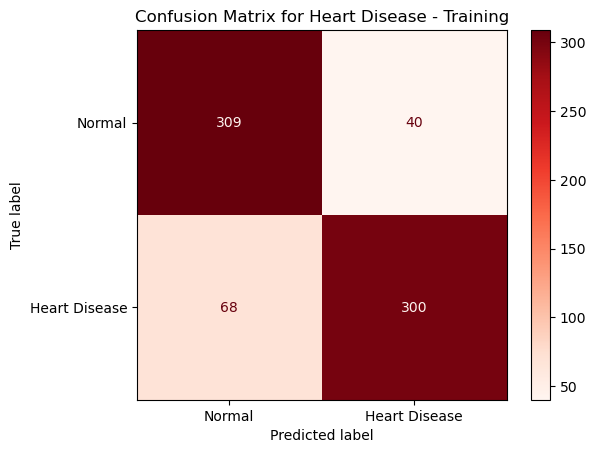

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_t = confusion_matrix(y_train, y_pd)
L1 = ['Normal', 'Heart Disease']
disp = ConfusionMatrixDisplay(confusion_matrix = cm_t,
                              display_labels = L1)
disp.plot(cmap = plt.cm.Reds)
plt.title('Confusion Matrix for Heart Disease - Training')
plt.show()

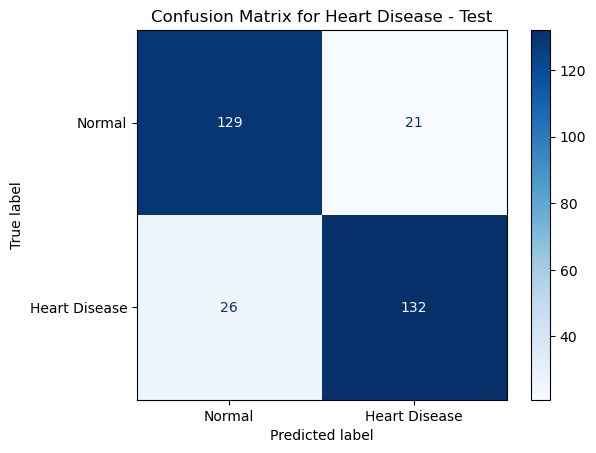

In [19]:
cm_tx = confusion_matrix(y_test, y_pd_test)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_tx,
                              display_labels = L1)
disp.plot(cmap = plt.cm.Blues)
plt.title('Confusion Matrix for Heart Disease - Test')
plt.show()

# Q10 - Decision Tree
- assign trained_tree to dt_pipeline.named_steps['classifier']
- assign importances the trained_tree.feature_importances_
- assign feature_names from preprocessor.get_feature_names_out()
- create a dictionary called tree = {'Feature' : feature_names, 'Importance' : importances}
- assign pd.DataFrame from tree and assign it to variable importance_df
- sort by 'Importance' ascending = False
- display importance_df
- In a new code cell, assign the name.split('__')[-1] for name in feature_names to a variable called clean_names
- importance_df['Feature'] = clean_names
- display importance_df

In [20]:
train_tree = dt_model.named_steps['clf']
importances = train_tree.feature_importances_
feature_names = preprocessor.get_feature_names_out()
dtree = {'Feature' : feature_names, 'Importance' : importances}
import_df = pd.DataFrame(dtree).sort_values(by = 'Importance', ascending = False)
import_df


,Feature,Importance
7,cat__cp_0,0.514548
16,cat__ca_0,0.147570
23,cat__thal_2,0.130100
0,num__age,0.097934
5,cat__sex_0,0.063860
4,num__oldpeak,0.033518
1,num__trestbps,0.012470
3,num__thalach,0.000000
2,num__chol,0.000000
8,cat__cp_1,0.000000


In [21]:
c_names = [name.split('__')[-1] for name in feature_names]
import_df['Feature'] = c_names
import_df

,Feature,Importance
7,age,0.514548
16,trestbps,0.147570
23,chol,0.130100
0,thalach,0.097934
5,oldpeak,0.063860
4,sex_0,0.033518
1,sex_1,0.012470
3,cp_0,0.000000
2,cp_1,0.000000
8,cp_2,0.000000


# Display Decision Tree
- from sklearn.tree import DecisionTreeClassifier, plot_tree
- create the figure size (20, 10) using plt.figure
- plot_tree(trained_tree, feature_names = X.columns,
-            class_names = L1, filled = True,
-            rounded = True, fontsize = 12)
- plt.title('Decision Tree: Top Nodes are the Most Important Features')
- plt.show()

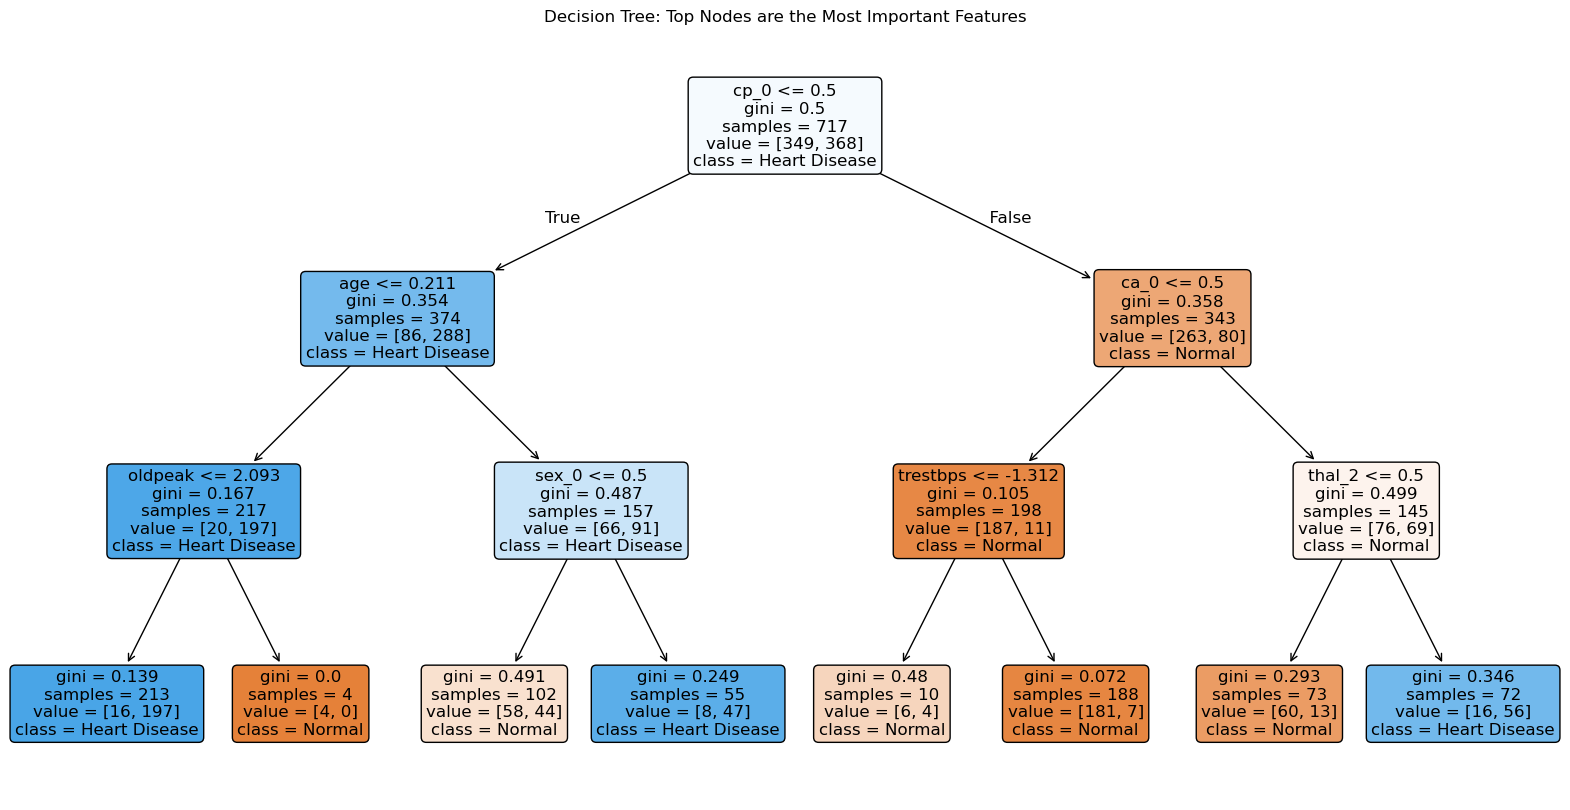

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.figure(figsize = (20, 10))
plot_tree(train_tree,
          feature_names = c_names,
          class_names = L1,
          filled = True,
          rounded = True,
          fontsize = 12)
plt.title('Decision Tree: Top Nodes are the Most Important Features')
plt.show()